In [1]:
%load_ext autoreload
%autoreload 2

from notebooks.features.feature_extraction import load_all_features

loaded_features = load_all_features(filenames=['sense_start.csv'], version='oligo', n_jobs=-1)

In [2]:
from notebooks.consts import PROCESSED_OLIGO_CSV_GZ, OLIGO_CSV_INDEXED
import pandas as pd

data = pd.read_csv(PROCESSED_OLIGO_CSV_GZ)

# Check if the column exists
if "index_oligo" not in data.columns:
    # Create the column starting at 1
    data["index_oligo"] = range(1, len(data) + 1)

    # Save the file
    data.to_csv(OLIGO_CSV_INDEXED, index=False)
    print("Added 'index_oligo' and saved file.")
else:
    print("'index_oligo' already exists. No changes made.")

Added 'index_oligo' and saved file.


In [3]:
import pandas as pd

merged_df = pd.merge(loaded_features, data, on='index_oligo')

In [15]:
from notebooks.preprocessing import process_oligo_data

# 785 with multiple target genes present were already eliminated previously
processed_data = process_oligo_data(merged_df, strict_gapmer_patterns=True)

------------------------------------------------------------
PROCESSING FILTERING REPORT
------------------------------------------------------------
Initial raw rows loaded: 158,725

[0. BASE FILTERING]
Unsupported chemistry (Mixmers/DNA/None): 20,040
Steric blocking (True) eliminated: 0
Multiple genes (';' present) eliminated: 0
Missing inhibition (NaN) eliminated: 0
Missing cell line (NaN) eliminated: 4,159

[1. UNMAPPED SEQUENCES (sense_start == -1)]
Samples eliminated: 752

[2. STRICT GAPMER PATTERNS (5-10-5 MOE / 3-10-3 cEt)]
Non standard sequences eliminated: 7,963

[3. COHORT FILTERING (>= 1 samples)]
Cohorts: 250 -> 250 (0 eliminated)
Samples: 125,811 -> 125,811 (0 eliminated)

[4. SPARSE CELL LINE FILTERING (>= 1 samples)]
Cell Lines: 29 -> 29 (0 eliminated)
Samples: 125,811 -> 125,811 (0 eliminated)

FINAL DATASET: 125,811 ASOs

ELIMINATED GROUPS BREAKDOWN

[ELIMINATED UNMAPPED SAMPLES] - 752 samples across 10 genes:
  • KCNQ2: 460 samples
  • IGF2-AS: 69 samples
  • RP11-73

In [16]:
from tauso.data.consts import INHIBITION
from notebooks.consts import OLIGO_CSV_INDEXED_AVERAGED # or wherever you want to save the output

# 2. Dynamically grab all feature columns (excluding the target and the index)
# This prevents you from having to hardcode hundreds of sequence features.
feature_cols = [col for col in processed_data.columns if col not in [INHIBITION, 'index_oligo']]

# 3. Group by the exact matching features, average the inhibition, and grab the first index
averaged_df = processed_data.groupby(feature_cols, as_index=False).agg({
    INHIBITION: 'mean',
    'index_oligo': 'first'
})

# 4. (Optional) Reorder the dataframe so your index is back at the front
final_cols = ['index_oligo'] + feature_cols + [INHIBITION]
averaged_df = averaged_df[final_cols]

# 5. Save the averaged dataset
averaged_df.to_csv(OLIGO_CSV_INDEXED_AVERAGED, index=False)
print(f"Collapsed data from {len(processed_data)} rows down to {len(averaged_df)} rows.")

Collapsed data from 125811 rows down to 106797 rows.


/tmp/ipykernel_13701/1746264661.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


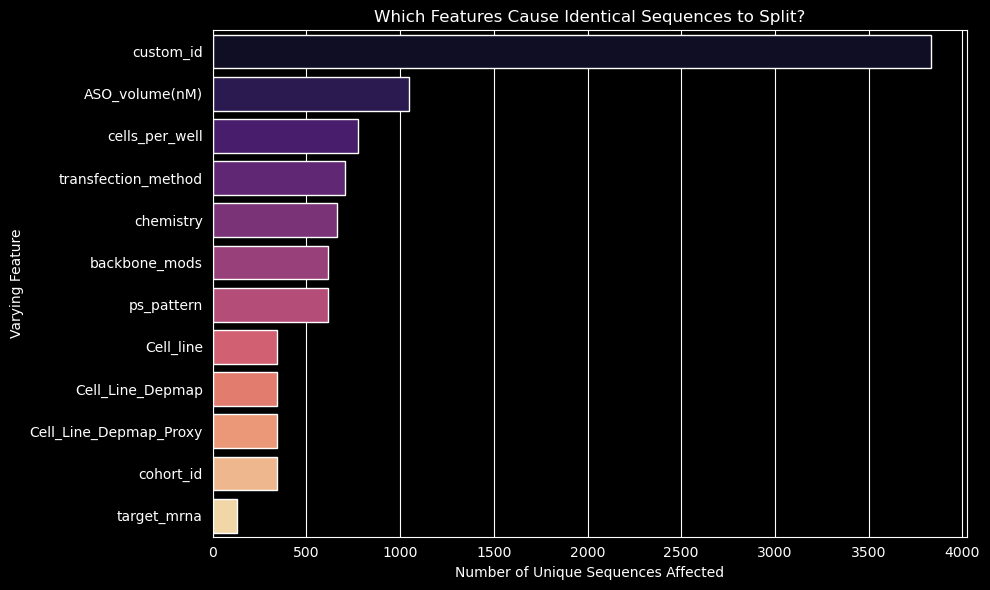

                   Feature  Number of Sequences Split
0                custom_id                       3834
2           ASO_volume(nM)                       1046
3           cells_per_well                        773
4      transfection_method                        707
8                chemistry                        666
9            backbone_mods                        617
10              ps_pattern                        617
1                Cell_line                        345
7         Cell_Line_Depmap                        345
6   Cell_Line_Depmap_Proxy                        345
5                cohort_id                        345
11             target_mrna                        129


In [17]:
from collections import defaultdict
from tauso.data.consts import SEQUENCE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate rows where the SEQUENCE appears more than once in averaged_df
duplicates_only = averaged_df[averaged_df.duplicated(subset=[SEQUENCE], keep=False)]

# 2. Dictionary to track how many unique sequences are split by each column
variation_counts = defaultdict(int)

# 3. Group by SEQUENCE and check which columns differ within each group
grouped_seqs = duplicates_only.groupby(SEQUENCE)

for seq, group in grouped_seqs:
    for col in group.columns:
        # Skip the sequence itself, the target, and the unique index
        if col in [SEQUENCE, INHIBITION, 'index_oligo']:
            continue

        # If this column has more than 1 unique value for this sequence, it caused a split
        if group[col].nunique(dropna=False) > 1:
            variation_counts[col] += 1

# 4. Convert the counts into a DataFrame for plotting
variation_df = pd.DataFrame(
    list(variation_counts.items()),
    columns=['Feature', 'Number of Sequences Split']
).sort_values(by='Number of Sequences Split', ascending=False)

# 5. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(
    data=variation_df,
    x='Number of Sequences Split',
    y='Feature',
    palette='magma'
)

plt.title("Which Features Cause Identical Sequences to Split?")
plt.xlabel("Number of Unique Sequences Affected")
plt.ylabel("Varying Feature")
plt.tight_layout()
plt.savefig("sequence_variation_plot.png") # Saves the plot to your directory
plt.show()

# Print the text summary as well
print(variation_df)

In [18]:
import pandas as pd

# 1. Isolate rows where BOTH SEQUENCE and custom_id are identical
subset_cols = [SEQUENCE, 'custom_id']
duplicates_only = averaged_df[averaged_df.duplicated(subset=subset_cols, keep=False)]

# 2. Find which columns vary within these specific groups
varying_columns = set()
grouped = duplicates_only.groupby(subset_cols)

for _, group in grouped:
    for col in group.columns:
        # Skip our grouping keys and our known variables
        if col in subset_cols + [INHIBITION, 'index_oligo']:
            continue

        # If there's more than 1 unique value, it's causing a split
        if group[col].nunique(dropna=False) > 1:
            varying_columns.add(col)

print("When both SEQUENCE and custom_id are identical, these columns differ:")
for col in sorted(varying_columns):
    print(f" - {col}")

# Optional: Peek at the actual varying values for the first group to see what's happening
if not duplicates_only.empty:
    first_group = list(grouped)[0][1]
    print("\nExample of differing values for the first duplicated pair:")
    for col in varying_columns:
        print(f" {col}: {first_group[col].unique()}")

When both SEQUENCE and custom_id are identical, these columns differ:
 - backbone_mods
 - chemistry
 - ps_pattern

Example of differing values for the first duplicated pair:
 ps_pattern: ['*******************' '*ddd***********dd**']
 chemistry: ["length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])]"
 "length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]"]
 backbone_mods: ["['PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', '<PAD>']"
 "['PS', 'PO', 'PO', 'PO', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PS', 'PO', 'PO', 'PS', 'PS', '<PAD>'

In [19]:
import pandas as pd
from collections import defaultdict

# 1. Isolate rows where BOTH SEQUENCE and custom_id are identical
subset_cols = [SEQUENCE, 'custom_id']
duplicates_only = averaged_df[averaged_df.duplicated(subset=subset_cols, keep=False)]

# 2. Dictionary to count how many unique (Sequence + ID) pairs are split by each feature
variation_counts = defaultdict(int)

# 3. Group by SEQUENCE and custom_id
grouped = duplicates_only.groupby(subset_cols)
total_duplicated_groups = len(grouped)

for _, group in grouped:
    for col in group.columns:
        if col in subset_cols + [INHIBITION, 'index_oligo']:
            continue

        # If there's more than 1 unique value, it caused a split for this specific sequence pair
        if group[col].nunique(dropna=False) > 1:
            variation_counts[col] += 1

# 4. Format and print the results
print(f"Total number of identical (SEQUENCE + custom_id) pairs found: {total_duplicated_groups}\n")
print("Number of times each feature caused these pairs to split into different rows:")
print("-" * 65)

# Sort by the highest counts
for col, count in sorted(variation_counts.items(), key=lambda item: item[1], reverse=True):
    percentage = (count / total_duplicated_groups) * 100
    print(f"{col:<25} | Split {count} pairs ({percentage:.1f}%)")

Total number of identical (SEQUENCE + custom_id) pairs found: 7

Number of times each feature caused these pairs to split into different rows:
-----------------------------------------------------------------
chemistry                 | Split 7 pairs (100.0%)
backbone_mods             | Split 7 pairs (100.0%)
ps_pattern                | Split 7 pairs (100.0%)
